In [1]:
import pandas as pd
import re

In [2]:
with open("WhatsApp Chat with IIT (ISM) Dhanbad JoSAA Helpdesk 26-27.txt",
          "r",
          encoding="utf-8") as f:

    data = f.read()

print(data[:500])

06/05/2026, 02:26 - ~ Om Mishra created group "IIT (ISM) Dhanbad JoSAA Helpdesk 26-27"
14/05/2026, 14:43 - You joined from the community
14/05/2026, 14:44 - +91 83683 50068 joined from the community
14/05/2026, 14:44 - +91 63954 86898 joined from the community
14/05/2026, 14:45 - +91 85339 66195 joined from the community
14/05/2026, 14:47 - +91 91197 30967 joined from the community
14/05/2026, 14:54 - +91 95693 63907 joined from the community
14/05/2026, 14:55 - +91 63934 32270 joined from the c


In [3]:
print(len(data))

1967489


In [4]:
print(data.split("\n")[:5])

['06/05/2026, 02:26 - ~\u202fOm Mishra created group "IIT (ISM) Dhanbad JoSAA Helpdesk 26-27"', '14/05/2026, 14:43 - You joined from the community', '14/05/2026, 14:44 - +91 83683 50068 joined from the community', '14/05/2026, 14:44 - +91 63954 86898 joined from the community', '14/05/2026, 14:45 - +91 85339 66195 joined from the community']


In [5]:
pattern = r'(\d{2}/\d{2}/\d{4}, \d{2}:\d{2}) - '

messages = re.split(pattern, data)

print(messages[:10])

['', '06/05/2026, 02:26', '~\u202fOm Mishra created group "IIT (ISM) Dhanbad JoSAA Helpdesk 26-27"\n', '14/05/2026, 14:43', 'You joined from the community\n', '14/05/2026, 14:44', '+91 83683 50068 joined from the community\n', '14/05/2026, 14:44', '+91 63954 86898 joined from the community\n', '14/05/2026, 14:45']


In [6]:
print(messages[1])
print("------")
print(messages[2])

06/05/2026, 02:26
------
~ Om Mishra created group "IIT (ISM) Dhanbad JoSAA Helpdesk 26-27"



In [7]:
dates = messages[1::2]
texts = messages[2::2]

print("Dates:", len(dates))
print("Texts:", len(texts))

Dates: 25543
Texts: 25543


In [8]:
df = pd.DataFrame({
    "date": dates,
    "message": texts
})

df.head()

,date,message
0,"06/05/2026, 02:26","~ Om Mishra created group ""IIT (ISM) Dhanbad J..."
1,"14/05/2026, 14:43",You joined from the community\n
2,"14/05/2026, 14:44",+91 83683 50068 joined from the community\n
3,"14/05/2026, 14:44",+91 63954 86898 joined from the community\n
4,"14/05/2026, 14:45",+91 85339 66195 joined from the community\n


In [9]:
df.shape

(25543, 2)

In [10]:
df.sample(5)

,date,message
11250,"23/05/2026, 17:01",+91 75059 22791: Bhai acche se baat kar rahe h...
8466,"22/05/2026, 11:41",+91 93418 63353: And what if interest aa jaaye?\n
14062,"25/05/2026, 22:23",+91 80037 50000: Baki to har course me nahi ch...
9503,"22/05/2026, 17:14","+91 99505 16838: obc 1000-1100 branch , jodhpu..."
21794,"29/05/2026, 14:48",+91 70299 08960: acchaa accha.... double major...


In [11]:
print("Total Messages:", df.shape[0])

Total Messages: 25543


In [12]:
df.head()

,date,message
0,"06/05/2026, 02:26","~ Om Mishra created group ""IIT (ISM) Dhanbad J..."
1,"14/05/2026, 14:43",You joined from the community\n
2,"14/05/2026, 14:44",+91 83683 50068 joined from the community\n
3,"14/05/2026, 14:44",+91 63954 86898 joined from the community\n
4,"14/05/2026, 14:45",+91 85339 66195 joined from the community\n


In [13]:
df.shape


(25543, 2)

In [14]:
print("Total Messages:", df.shape[0])

Total Messages: 25543


In [15]:
users = []
messages_text = []

for message in df['message']:

    entry = re.split(r'([^:]+):\s', message)

    if len(entry) >= 3:
        users.append(entry[1])
        messages_text.append(entry[2])

    else:
        users.append("group_notification")
        messages_text.append(message)

In [16]:
df['user'] = users
df['message_text'] = messages_text

df.head()

,date,message,user,message_text
0,"06/05/2026, 02:26","~ Om Mishra created group ""IIT (ISM) Dhanbad J...",group_notification,"~ Om Mishra created group ""IIT (ISM) Dhanbad J..."
1,"14/05/2026, 14:43",You joined from the community\n,group_notification,You joined from the community\n
2,"14/05/2026, 14:44",+91 83683 50068 joined from the community\n,group_notification,+91 83683 50068 joined from the community\n
3,"14/05/2026, 14:44",+91 63954 86898 joined from the community\n,group_notification,+91 63954 86898 joined from the community\n
4,"14/05/2026, 14:45",+91 85339 66195 joined from the community\n,group_notification,+91 85339 66195 joined from the community\n


In [17]:
df['user'].unique()[:20]

array(['group_notification', '+91 80037 50000', '+91 88823 10664',
       '+91 76760 08217', '+91 95084 71202', '+91 78119 17720',
       '+91 70219 56466', '+91 79871 52046', '+91 87805 31911',
       '+91 62839 17075', '+91 84602 13237', '+91 97295 96299',
       '+91 70146 29086', '+91 70139 47068', '+91 94727 44347',
       '+91 63592 63003', '+91 92041 14115', '+91 99250 34220', 'Manu',
       '+91 6355 487 580'], dtype=object)

In [18]:
df['user'].value_counts().head(10)

,count
user,
+91 76760 08217,2178
+91 94727 44347,1326
+91 97736 97089,1199
+91 93418 63353,1164
+91 80037 50000,1069
group_notification,1065
+91 97295 96299,1047
+91 88999 20030,999
+91 92041 14115,912


In [19]:
df['user'].value_counts().head(10)

,count
user,
+91 76760 08217,2178
+91 94727 44347,1326
+91 97736 97089,1199
+91 93418 63353,1164
+91 80037 50000,1069
group_notification,1065
+91 97295 96299,1047
+91 88999 20030,999
+91 92041 14115,912


In [20]:
import matplotlib.pyplot as plt

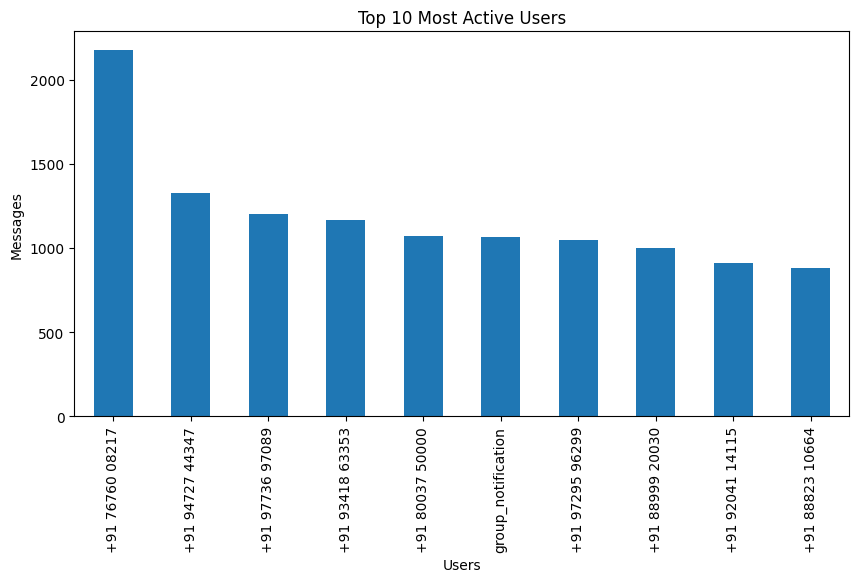

In [21]:
top_users = df['user'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_users.plot(kind='bar')

plt.title("Top 10 Most Active Users")
plt.xlabel("Users")
plt.ylabel("Messages")

plt.show()

In [22]:
df_users = df[df['user'] != 'group_notification']

In [23]:
print("Total Users:", df_users['user'].nunique())

Total Users: 438


In [24]:
from collections import Counter

In [26]:
words = []

for msg in df_users['message_text']:
    words.extend(msg.lower().split())

In [27]:
freq = Counter(words)

freq.most_common(20)

[('hai', 4250),
 ('to', 2753),
 ('bhai', 1959),
 ('me', 1841),
 ('and', 1532),
 ('bhi', 1514),
 ('ke', 1503),
 ('h', 1497),
 ('is', 1410),
 ('se', 1403),
 ('in', 1367),
 ('ka', 1268),
 ('the', 1253),
 ('you', 1177),
 ('hi', 1136),
 ('i', 1112),
 ('<media', 1089),
 ('omitted>', 1089),
 ('nahi', 1033),
 ('toh', 925)]

In [29]:
stop_words = [
    "hai","ki","ka","ke","ko","se","aur","to","me",
    "mai","main","is","the","a","an","of","for",
    "in","on","at","ho","ha","h","ya","na",
    "bhai", "and", "bhi", "you", "hi", "i", "<media", "omitted>", "nahi", "toh"
]

In [30]:
clean_words = []

for word in words:

    word = word.strip()

    if word not in stop_words and len(word) > 2:
        clean_words.append(word)

In [31]:
from collections import Counter

clean_freq = Counter(clean_words)

clean_freq.most_common(20)

[('but', 907),
 ('was', 887),
 ('kya', 853),
 ('nhi', 807),
 ('branch', 780),
 ('message', 765),
 ('iit', 741),
 ('mein', 741),
 ('tha', 687),
 ('are', 676),
 ('core', 624),
 ('this', 568),
 ('ism', 513),
 ('kuch', 495),
 ('year', 477),
 ('better', 475),
 ('dhanbad', 475),
 ('cse', 474),
 ('college', 470),
 ('can', 457)]

In [32]:
clean_words = []

for word in words:

    word = word.strip()

    if word not in stop_words and len(word) > 2:
        clean_words.append(word)

from collections import Counter

clean_freq = Counter(clean_words)

print(clean_freq.most_common(20))

[('but', 907), ('was', 887), ('kya', 853), ('nhi', 807), ('branch', 780), ('message', 765), ('iit', 741), ('mein', 741), ('tha', 687), ('are', 676), ('core', 624), ('this', 568), ('ism', 513), ('kuch', 495), ('year', 477), ('better', 475), ('dhanbad', 475), ('cse', 474), ('college', 470), ('can', 457)]


In [33]:
!pip install wordcloud

In [34]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [35]:
text = " ".join(clean_words)

In [36]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

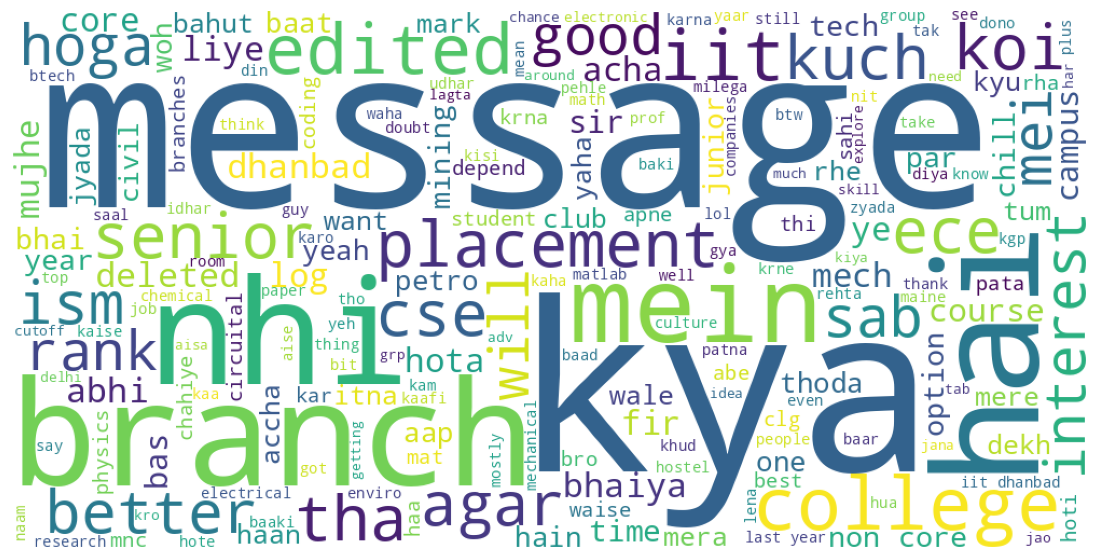

In [37]:
plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [38]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 18.8 MB/s eta 0:00:00


In [39]:
import emoji
from collections import Counter

In [40]:
emojis = []

for msg in df_users['message_text']:

    for char in msg:

        if char in emoji.EMOJI_DATA:
            emojis.append(char)

In [41]:
emoji_count = Counter(emojis)

emoji_count.most_common(20)

[('😭', 673),
 ('😂', 499),
 ('🥀', 350),
 ('🙏', 247),
 ('💔', 200),
 ('🥲', 133),
 ('🤣', 111),
 ('🫠', 103),
 ('🏻', 98),
 ('💀', 92),
 ('🙂', 81),
 ('😔', 74),
 ('🥰', 71),
 ('🥺', 71),
 ('❤', 67),
 ('✌', 66),
 ('🔥', 64),
 ('😹', 62),
 ('😋', 56),
 ('🤔', 50)]

In [42]:
emoji_count.most_common(20)

[('😭', 673),
 ('😂', 499),
 ('🥀', 350),
 ('🙏', 247),
 ('💔', 200),
 ('🥲', 133),
 ('🤣', 111),
 ('🫠', 103),
 ('🏻', 98),
 ('💀', 92),
 ('🙂', 81),
 ('😔', 74),
 ('🥰', 71),
 ('🥺', 71),
 ('❤', 67),
 ('✌', 66),
 ('🔥', 64),
 ('😹', 62),
 ('😋', 56),
 ('🤔', 50)]

In [43]:
!pip install textblob

In [44]:
from textblob import TextBlob

In [45]:
TextBlob("I am very happy").sentiment

Sentiment(polarity=1.0, subjectivity=1.0)

In [46]:
TextBlob("I hate this").sentiment.polarity

-0.8

In [47]:
def get_sentiment(text):

    score = TextBlob(str(text)).sentiment.polarity

    if score > 0:
        return "Positive"

    elif score < 0:
        return "Negative"

    else:
        return "Neutral"

In [48]:
df_users['sentiment'] = df_users['message_text'].apply(get_sentiment)

/tmp/ipykernel_2058/3339056189.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_users['sentiment'] = df_users['message_text'].apply(get_sentiment)


In [49]:
df_users[['message_text','sentiment']].head(10)

,message_text,sentiment
25,Msg pinned se hata dena link online dalne se p...,Neutral
26,😭😭😭😭\n,Neutral
27,Done\n,Neutral
28,Bhai isi group me 600+ log hai\n,Neutral
29,🥀\n,Neutral
30,💀\n,Neutral
31,Sophomores hai na sirf?\n,Neutral
32,@⁨all⁩ jo jo jossa councelling k time active n...,Negative
41,<Media omitted>\n,Neutral
42,<Media omitted>\n,Neutral


In [50]:
df_users['sentiment'].value_counts()

,count
sentiment,
Neutral,19076
Positive,3631
Negative,1771


In [51]:
df['date']

,date
0,"06/05/2026, 02:26"
1,"14/05/2026, 14:43"
2,"14/05/2026, 14:44"
3,"14/05/2026, 14:44"
4,"14/05/2026, 14:45"
...,...
25538,"31/05/2026, 12:53"
25539,"31/05/2026, 12:55"
25540,"31/05/2026, 12:55"
25541,"31/05/2026, 12:56"


In [54]:
df['date'] = pd.to_datetime(
    df['date'],
    format='%d/%m/%Y, %H:%M'
)

In [58]:
df_users['date'] = pd.to_datetime(df_users['date'], format='%d/%m/%Y, %H:%M')
df_users['month'] = df_users['date'].dt.month

/tmp/ipykernel_2058/1116580295.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_users['date'] = pd.to_datetime(df_users['date'], format='%d/%m/%Y, %H:%M')
/tmp/ipykernel_2058/1116580295.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_users['month'] = df_users['date'].dt.month


In [59]:
df_users[['date','month']].head()

,date,month
25,2026-05-15 14:43:00,5
26,2026-05-15 14:44:00,5
27,2026-05-15 14:44:00,5
28,2026-05-15 14:44:00,5
29,2026-05-15 14:44:00,5


In [60]:
monthly = df_users['month'].value_counts().sort_index()

print(monthly)

month
5    24478
Name: count, dtype: int64


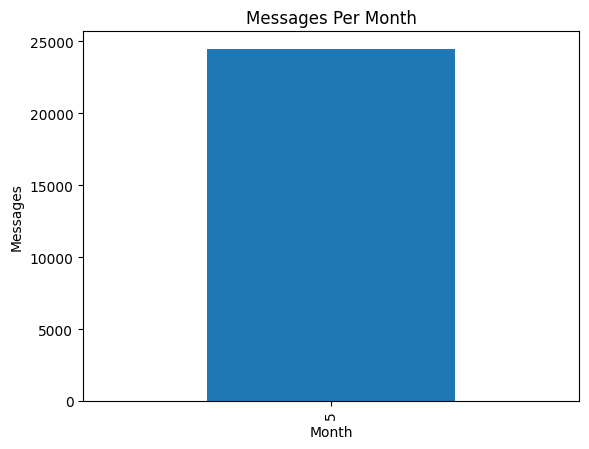

In [61]:
import matplotlib.pyplot as plt

monthly.plot(kind='bar')

plt.title("Messages Per Month")
plt.xlabel("Month")
plt.ylabel("Messages")

plt.show()

In [63]:
df['date'] = pd.to_datetime(
    df['date'],
    format='%d/%m/%Y, %H:%M'
)

In [64]:

df_users['month'] = df_users['date'].dt.month

/tmp/ipykernel_2058/152290653.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_users['month'] = df_users['date'].dt.month


In [65]:
df_users[['date','month']].head()

,date,month
25,2026-05-15 14:43:00,5
26,2026-05-15 14:44:00,5
27,2026-05-15 14:44:00,5
28,2026-05-15 14:44:00,5
29,2026-05-15 14:44:00,5


In [68]:
monthly = df_users['month'].value_counts()
print(monthly)

month
5    24478
Name: count, dtype: int64


In [69]:
monthly = df_users['month'].value_counts().sort_index()

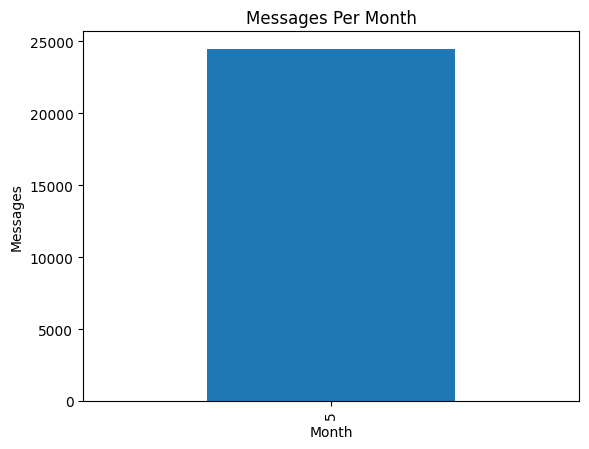

In [70]:
import matplotlib.pyplot as plt

monthly.plot(kind='bar')

plt.title("Messages Per Month")
plt.xlabel("Month")
plt.ylabel("Messages")

plt.show()

In [71]:
df_users['hour'] = df_users['date'].dt.hour

/tmp/ipykernel_2058/2400352150.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_users['hour'] = df_users['date'].dt.hour


In [72]:
hourly = df_users['hour'].value_counts().sort_index()

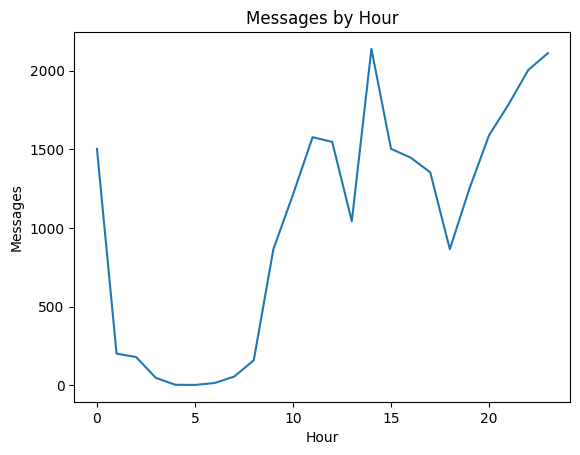

In [73]:
import matplotlib.pyplot as plt

hourly.plot(kind='line')

plt.title("Messages by Hour")
plt.xlabel("Hour")
plt.ylabel("Messages")

plt.show()

In [74]:
df_users['day'] = df_users['date'].dt.day

/tmp/ipykernel_2058/3968457514.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_users['day'] = df_users['date'].dt.day


In [75]:
daily = df_users['day'].value_counts().sort_index()

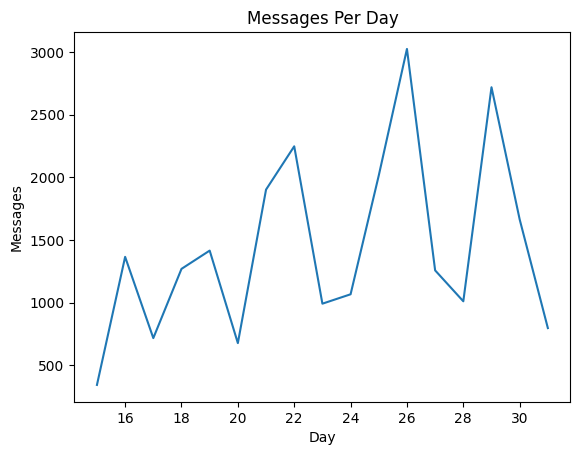

In [76]:
daily.plot(kind='line')

plt.title("Messages Per Day")
plt.xlabel("Day")
plt.ylabel("Messages")

plt.show()

In [77]:
df_users['only_date'] = df_users['date'].dt.date

/tmp/ipykernel_2058/2003130757.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_users['only_date'] = df_users['date'].dt.date


In [78]:
timeline = df_users['only_date'].value_counts().sort_index()

In [79]:
df_users['day_name'] = df_users['date'].dt.day_name()

/tmp/ipykernel_2058/1438166505.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_users['day_name'] = df_users['date'].dt.day_name()


In [80]:
df_users[['date','day_name']].head()

,date,day_name
25,2026-05-15 14:43:00,Friday
26,2026-05-15 14:44:00,Friday
27,2026-05-15 14:44:00,Friday
28,2026-05-15 14:44:00,Friday
29,2026-05-15 14:44:00,Friday


In [81]:
weekday_activity = df_users['day_name'].value_counts()

print(weekday_activity)

day_name
Friday       5310
Tuesday      4441
Saturday     4020
Monday       3284
Thursday     2912
Sunday       2578
Wednesday    1933
Name: count, dtype: int64


In [82]:
days = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

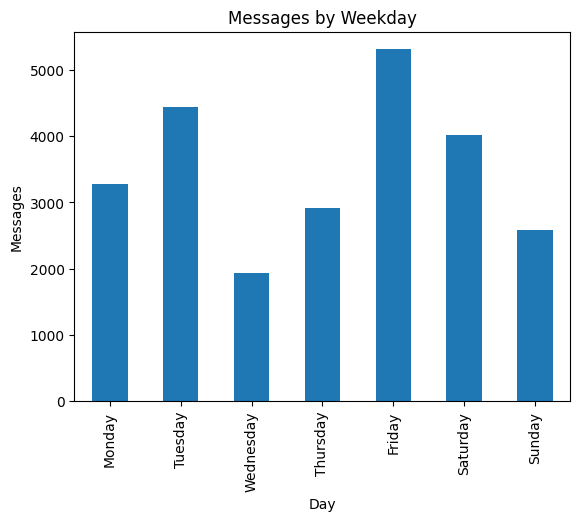

In [83]:
weekday_activity.reindex(days).plot(kind='bar')

plt.title("Messages by Weekday")
plt.xlabel("Day")
plt.ylabel("Messages")

plt.show()

In [84]:
activity_map = df_users.pivot_table(
    index='day_name',
    columns='hour',
    values='message_text',
    aggfunc='count'
)

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

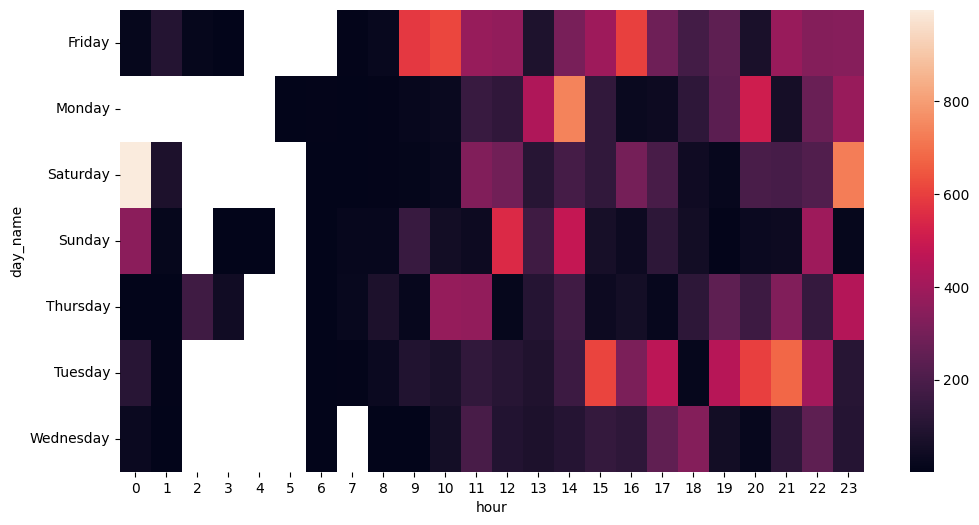

In [86]:
plt.figure(figsize=(12,6))

sns.heatmap(activity_map)

plt.show()

In [88]:
plt.figure(figsize=(12,6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_name,,,,,,,,,,,,,,,,,,,,,
Friday,14.0,97.0,14.0,1.0,NaN,NaN,NaN,6.0,22.0,583.0,...,308.0,393.0,601.0,282.0,180.0,243.0,71.0,381.0,335.0,338.0
Monday,NaN,NaN,NaN,NaN,NaN,3.0,8.0,1.0,7.0,19.0,...,739.0,131.0,25.0,35.0,124.0,236.0,511.0,56.0,271.0,381.0
Saturday,998.0,75.0,NaN,NaN,NaN,NaN,1.0,1.0,5.0,10.0,...,183.0,133.0,298.0,188.0,40.0,20.0,194.0,185.0,213.0,729.0
Sunday,350.0,15.0,NaN,1.0,4.0,NaN,1.0,19.0,19.0,149.0,...,481.0,61.0,35.0,118.0,51.0,5.0,31.0,33.0,393.0,14.0
Thursday,3.0,4.0,166.0,46.0,NaN,NaN,3.0,22.0,77.0,17.0,...,172.0,36.0,54.0,20.0,121.0,246.0,163.0,325.0,144.0,443.0
Tuesday,107.0,7.0,NaN,NaN,NaN,NaN,1.0,7.0,29.0,87.0,...,157.0,612.0,313.0,463.0,16.0,451.0,600.0,682.0,405.0,106.0
Wednesday,32.0,4.0,NaN,NaN,NaN,NaN,1.0,NaN,1.0,1.0,...,99.0,138.0,122.0,249.0,334.0,50.0,20.0,125.0,244.0,101.0


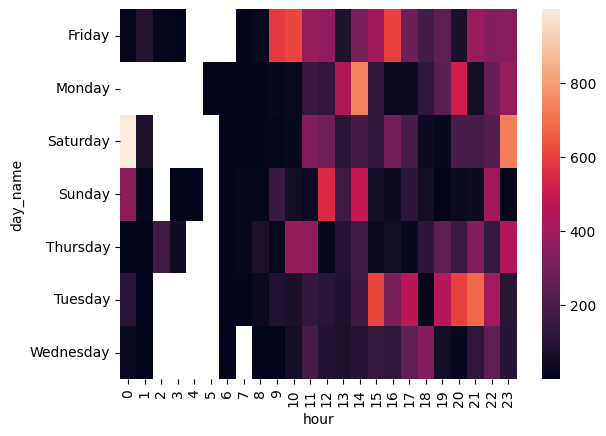

In [89]:
sns.heatmap(activity_map)
activity_map
activity_map

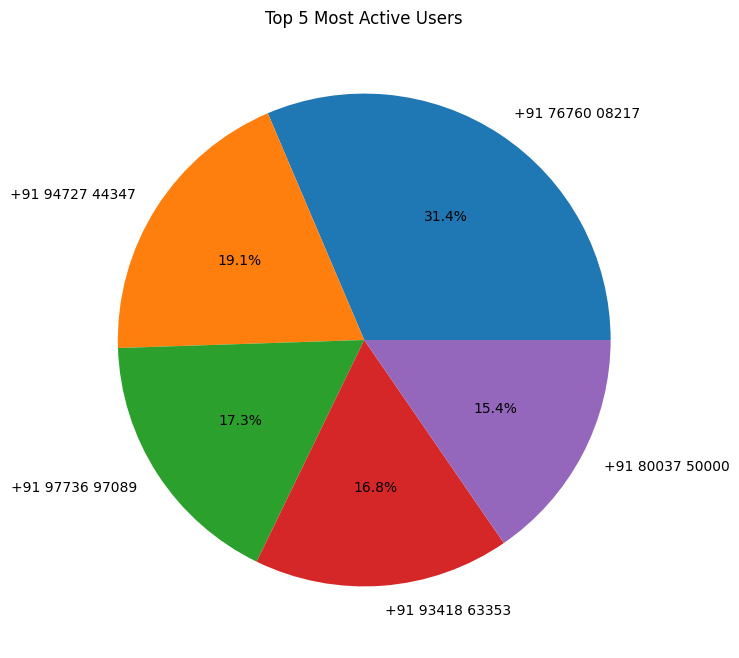

In [92]:
top_users = df_users['user'].value_counts().head(5)
plt.figure(figsize=(8,8))

top_users.plot(kind='pie', autopct='%1.1f%%')

plt.ylabel('')
plt.title("Top 5 Most Active Users")

plt.show()

In [93]:
from nltk.util import bigrams

In [94]:
all_bigrams = list(bigrams(clean_words))

In [98]:
from collections import Counter
bigram_freq = Counter(all_bigrams)
bigram_freq.most_common(20)

[(('message', 'was'), 749),
 (('<this', 'message'), 452),
 (('was', 'edited>'), 452),
 (('this', 'message'), 298),
 (('was', 'deleted'), 297),
 (('non', 'core'), 164),
 (('last', 'year'), 114),
 (('iit', 'dhanbad'), 98),
 (('branch', 'change'), 62),
 (('there', 'are'), 56),
 (('mil', 'rha'), 54),
 (('@\u2068~prav', 'prateek\u2069'), 54),
 (('can', 'get'), 49),
 (('better', 'than'), 48),
 (('campus', 'life'), 46),
 (('@\u2068~shresth', 'porwal\u2069'), 46),
 (('iit', 'ism'), 45),
 (('double', 'major'), 45),
 (('@\u2068~arindam', 'chakraborty\u2069'), 44),
 (('rha', 'tha'), 44)]

In [102]:
from nltk.util import trigrams
all_trigrams = list(trigrams(clean_words))
trigram_freq = Counter(all_trigrams)
trigram_freq.most_common(20)


[(('<this', 'message', 'was'), 452),
 (('message', 'was', 'edited>'), 452),
 (('this', 'message', 'was'), 297),
 (('message', 'was', 'deleted'), 297),
 (('was', 'deleted', 'this'), 25),
 (('deleted', 'this', 'message'), 25),
 (('core', 'non', 'core'), 16),
 (('@\u2068~abhishek', 'kumar', 'gupta\u2069'), 15),
 (('kya', 'mil', 'rha'), 12),
 (('was', 'edited>', 'this'), 10),
 (('non', 'core', 'liye'), 10),
 (('physics', 'mein', 'interest'), 10),
 (('@\u2068~satya', 'vardhan', 'singh\u2069'), 9),
 (('edited>', 'this', 'message'), 9),
 (('tha', 'last', 'year'), 8),
 (('iit', 'dhanbad', 'chemical'), 8),
 (('zero', 'percent', 'attendance'), 7),
 (('was', 'edited>', 'but'), 7),
 (('there', 'are', 'courses'), 7),
 (('was', 'edited>', 'iit'), 7)]

In [103]:
def preprocess(data):

    pattern = r'(\d{2}/\d{2}/\d{4}, \d{2}:\d{2}) - '

    messages = re.split(pattern, data)

    dates = messages[1::2]
    texts = messages[2::2]

    df = pd.DataFrame({
        'date': dates,
        'message': texts
    })

    return df

In [104]:
df_test = preprocess(data)

df_test.head()
preprocess(data)
preprocess(data)

,date,message
0,"06/05/2026, 02:26","~ Om Mishra created group ""IIT (ISM) Dhanbad J..."
1,"14/05/2026, 14:43",You joined from the community\n
2,"14/05/2026, 14:44",+91 83683 50068 joined from the community\n
3,"14/05/2026, 14:44",+91 63954 86898 joined from the community\n
4,"14/05/2026, 14:45",+91 85339 66195 joined from the community\n
...,...,...
25538,"31/05/2026, 12:53",+91 78119 17720: @⁨~Adhiraj Singh⁩ hi\n
25539,"31/05/2026, 12:55",~ Harshitha joined using a group link.\n
25540,"31/05/2026, 12:55",Jay kumar Maurya: \n
25541,"31/05/2026, 12:56",+91 93393 46446 joined using a group link.\n


In [105]:
entry = re.split(r'([^:]+):\s', message)
sample = df_test['message'][10]

print(sample)

+91 89578 33156 joined from the community



In [106]:
sample = df_test['message'][10]

print(sample)

+91 89578 33156 joined from the community



In [108]:
sample = df_test['message'][10]

print(sample)

+91 89578 33156 joined from the community



In [110]:
users = []
messages = []

for msg in df_test['message']:

    if ':' in msg:

        user, message_text = msg.split(':', 1)

        users.append(user)
        messages.append(message_text)

    else:

        users.append('group_notification')
        messages.append(msg)

In [112]:
df = pd.DataFrame({
    'date': dates,
    'user': users,
    'message_text': messages
})
df.head()

,date,user,message_text
0,"06/05/2026, 02:26",group_notification,"~ Om Mishra created group ""IIT (ISM) Dhanbad J..."
1,"14/05/2026, 14:43",group_notification,You joined from the community\n
2,"14/05/2026, 14:44",group_notification,+91 83683 50068 joined from the community\n
3,"14/05/2026, 14:44",group_notification,+91 63954 86898 joined from the community\n
4,"14/05/2026, 14:45",group_notification,+91 85339 66195 joined from the community\n


In [113]:
import pandas as pd

# 1. DataFrame banao

df = pd.DataFrame({
    'date': dates,
    'user': users,
    'message_text': messages
})

# 2. Group notifications hatao

df = df[df['user'] != 'group_notification']

# 3. Date ko datetime mein convert karo

df['date'] = pd.to_datetime(
    df['date'],
    format='%d/%m/%Y, %H:%M'
)

# 4. Date Toolbox 🧰

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['hour'] = df['date'].dt.hour
df['minute'] = df['date'].dt.minute
df['day_name'] = df['date'].dt.day_name()

# 5. Index reset karo

df.reset_index(drop=True, inplace=True)

# 6. Check output

print("Total Messages:", len(df))
print("Total Users:", df['user'].nunique())

df.head()

Total Messages: 24481
Total Users: 440


,date,user,message_text,year,month,day,hour,minute,day_name
0,2026-05-15 14:43:00,+91 80037 50000,Msg pinned se hata dena link online dalne se ...,2026,5,15,14,43,Friday
1,2026-05-15 14:44:00,+91 88823 10664,😭😭😭😭\n,2026,5,15,14,44,Friday
2,2026-05-15 14:44:00,+91 88823 10664,Done\n,2026,5,15,14,44,Friday
3,2026-05-15 14:44:00,+91 76760 08217,Bhai isi group me 600+ log hai\n,2026,5,15,14,44,Friday
4,2026-05-15 14:44:00,+91 76760 08217,🥀\n,2026,5,15,14,44,Friday


In [ ]:
 fetch_stats(df):

    total_messages = df.shape[0]

    total_users = df['user'].nunique()

    total_words = []
def
    for msg in df['message_text']:
        total_words.extend(msg.split())

    return total_messages, total_users, len(total_words)

In [115]:
total_messages, total_users, total_words = fetch_stats(df)

print(total_messages)
print(total_users)
print(total_words)

24481
440
190260


📊 WHATSAPP ANALYSIS REPORT
📩 Total Messages : 24481
👥 Total Users    : 440
📝 Total Words    : 190260

🏆 TOP 10 USERS
----------------------------------------
user
+91 76760 08217    2178
+91 94727 44347    1326
+91 97736 97089    1199
+91 93418 63353    1164
+91 80037 50000    1069
+91 97295 96299    1047
+91 88999 20030     999
+91 92041 14115     912
+91 88823 10664     883
+91 81149 99866     721
Name: count, dtype: int64


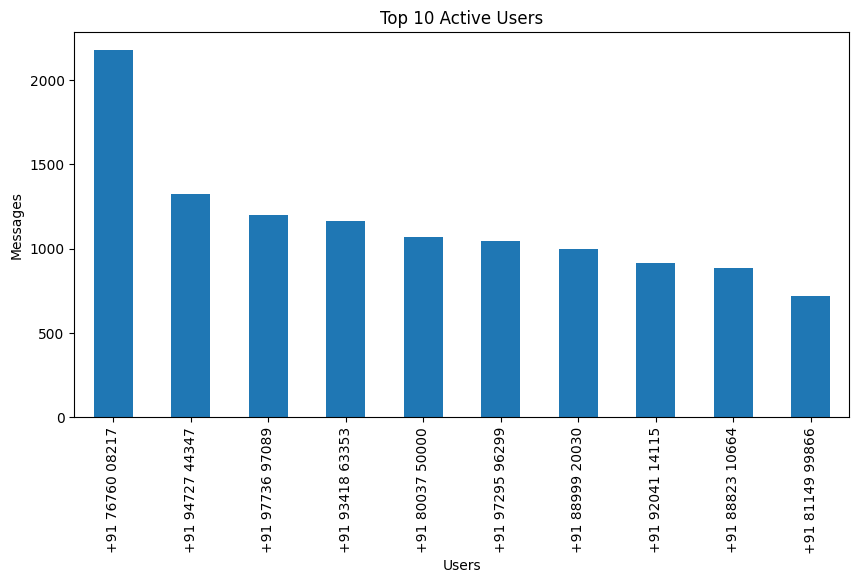

In [117]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# STATS MACHINE 🤖
# =========================

def fetch_stats(df):

    total_messages = df.shape[0]

    total_users = df['user'].nunique()

    total_words = []

    for msg in df['message_text']:
        total_words.extend(str(msg).split())

    return total_messages, total_users, len(total_words)


# =========================
# TOP USERS MACHINE 🏆
# =========================

def top_users(df):

    return df['user'].value_counts().head(10)


# =========================
# RUN ANALYSIS 🚀
# =========================

total_messages, total_users, total_words = fetch_stats(df)

print("="*40)
print("📊 WHATSAPP ANALYSIS REPORT")
print("="*40)

print(f"📩 Total Messages : {total_messages}")
print(f"👥 Total Users    : {total_users}")
print(f"📝 Total Words    : {total_words}")

print("\n🏆 TOP 10 USERS")
print("-"*40)

top = top_users(df)

print(top)

# =========================
# GRAPH 📈
# =========================

plt.figure(figsize=(10,5))

top.plot(kind='bar')

plt.title("Top 10 Active Users")
plt.xlabel("Users")
plt.ylabel("Messages")

plt.show()

In [118]:
from wordcloud import WordCloud

def create_wordcloud(clean_words):

    text = " ".join(clean_words)

    wc = WordCloud(
        width=1000,
        height=500,
        background_color='white'
    ).generate(text)

    return wc

📊 WHATSAPP CHAT ANALYZER REPORT
📩 Total Messages : 24481
👥 Total Users    : 440
📝 Total Words    : 190260

🏆 TOP 10 USERS
--------------------------------------------------
user
+91 76760 08217    2178
+91 94727 44347    1326
+91 97736 97089    1199
+91 93418 63353    1164
+91 80037 50000    1069
+91 97295 96299    1047
+91 88999 20030     999
+91 92041 14115     912
+91 88823 10664     883
+91 81149 99866     721
Name: count, dtype: int64


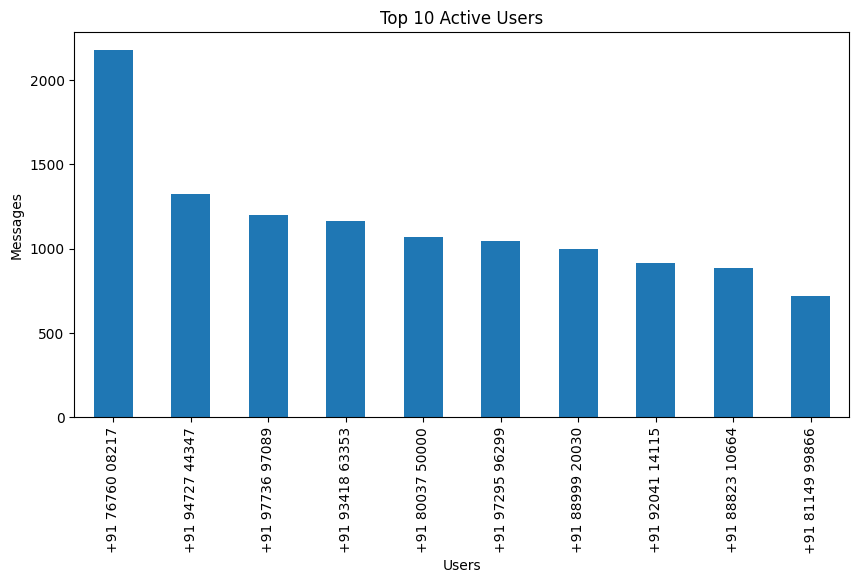

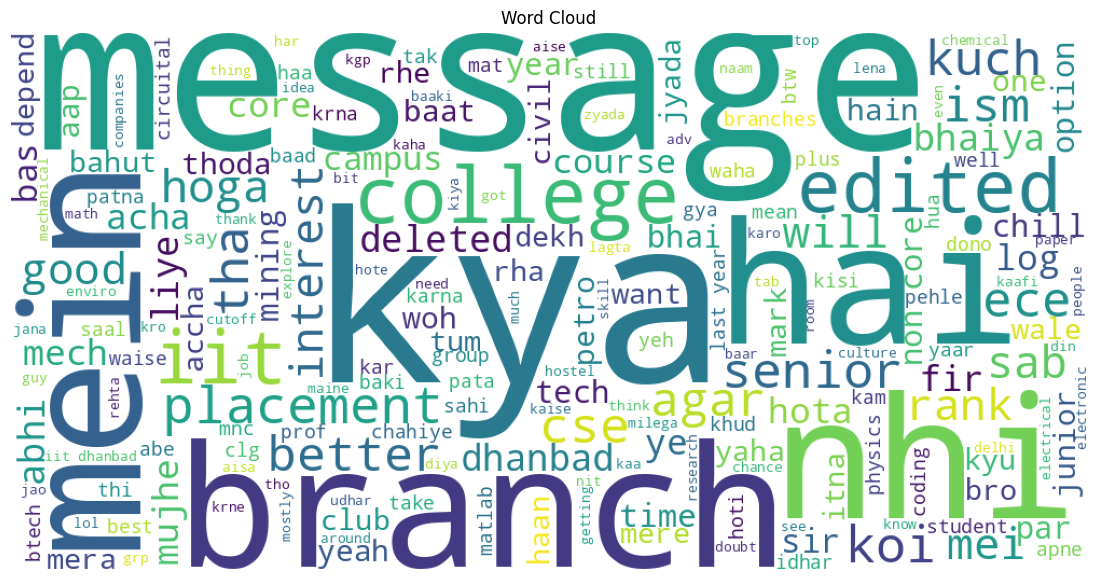

In [120]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# =====================================
# 🤖 STATS MACHINE
# =====================================

def fetch_stats(df):

    total_messages = df.shape[0]

    total_users = df['user'].nunique()

    total_words = []

    for msg in df['message_text']:
        total_words.extend(str(msg).split())

    return total_messages, total_users, len(total_words)


# =====================================
# 🏆 TOP USERS MACHINE
# =====================================

def top_users(df):

    return df['user'].value_counts().head(10)


# =====================================
# ☁️ WORDCLOUD MACHINE
# =====================================

def create_wordcloud(clean_words):

    text = " ".join(clean_words)

    wc = WordCloud(
        width=1000,
        height=500,
        background_color='white'
    ).generate(text)

    return wc


# =====================================
# 🚀 RUN ANALYSIS
# =====================================

total_messages, total_users, total_words = fetch_stats(df)

print("="*50)
print("📊 WHATSAPP CHAT ANALYZER REPORT")
print("="*50)

print(f"📩 Total Messages : {total_messages}")
print(f"👥 Total Users    : {total_users}")
print(f"📝 Total Words    : {total_words}")

print("\n🏆 TOP 10 USERS")
print("-"*50)

top = top_users(df)

print(top)

# =====================================
# 📈 TOP USERS GRAPH
# =====================================

plt.figure(figsize=(10,5))

top.plot(kind='bar')

plt.title("Top 10 Active Users")
plt.xlabel("Users")
plt.ylabel("Messages")

plt.show()

# =====================================
# ☁️ WORD CLOUD
# =====================================

wc = create_wordcloud(clean_words)

plt.figure(figsize=(15,7))

plt.imshow(wc)

plt.axis("off")

plt.title("Word Cloud")

plt.show()

month
5    24481
Name: message_text, dtype: int64


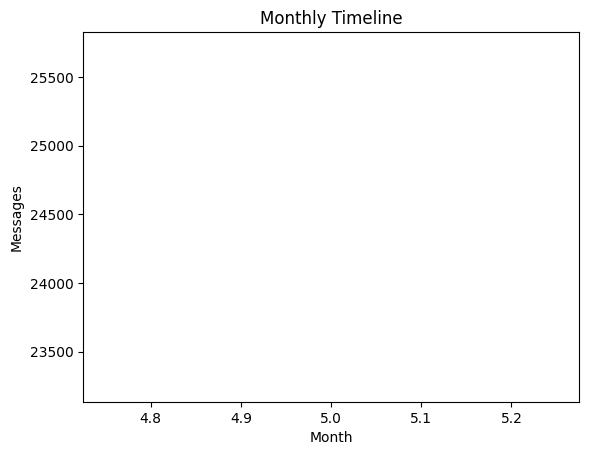

In [122]:
monthly = df.groupby('month')['message_text'].count()

print(monthly)
import matplotlib.pyplot as plt

monthly.plot()

plt.xlabel("Month")
plt.ylabel("Messages")
plt.title("Monthly Timeline")

plt.show()